# Unidade III — Pré-processamento de Dados

## Redução de dados

**Carga estimada:** 2 horas  
**Pré-requisitos:** álgebra linear básica, variância, pandas e NumPy.

> **Pergunta norteadora:** quanto podemos reduzir linhas ou atributos preservando a informação necessária à tarefa?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir amostragem, agregação, seleção e extração de atributos;
- aplicar amostragem estratificada e agregação com finalidade declarada;
- interpretar componentes principais e variância explicada;
- medir o compromisso entre compressão e perda de informação.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")


## Quatro formas de reduzir

**Amostragem** seleciona objetos; **agregação** substitui registros detalhados por resumos; **seleção de atributos** mantém parte das colunas originais; **extração de atributos** cria uma representação de menor dimensão. A escolha depende da pergunta. Agregar por mês pode servir para tendências e impedir a análise de eventos diários; remover uma coluna redundante preserva interpretação melhor que substituir todas por combinações abstratas.


In [2]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target.rename("diagnostico")
_, X_amostra, _, y_amostra = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
pd.DataFrame({
    "completo": y.value_counts(normalize=True).sort_index(),
    "amostra_estratificada": y_amostra.value_counts(normalize=True).sort_index(),
}).round(3)


,completo,amostra_estratificada
diagnostico,,
0,0.373,0.368
1,0.627,0.632


A estratificação preserva aproximadamente a proporção do diagnóstico, mas não garante representatividade para idade, local ou período, que nem sequer aparecem neste conjunto. Uma amostra aleatória não corrige viés da população originalmente coletada.

Agregação também exige declarar a unidade resultante. A média de atributos por diagnóstico, por exemplo, produz apenas duas linhas e serve para comparação descritiva, não para avaliar variação individual nem treinar honestamente um classificador de pacientes.


In [3]:
dados = X.assign(diagnostico=y)
agregado = dados.groupby("diagnostico")[["mean radius", "mean texture", "mean area"]].agg(["mean", "std", "count"]).round(2)
agregado


mean radius             mean texture             mean area  \
                   mean   std count         mean   std count      mean   
diagnostico                                                              
0                 17.46  3.20   212        21.60  3.78   212    978.38   
1                 12.15  1.78   357        17.91  4.00   357    462.79   

                           
                std count  
diagnostico                
0            367.94   212  
1            134.29   357

## Análise de Componentes Principais

A Análise de Componentes Principais (PCA) procura direções ortogonais de máxima variância. Para dados centralizados $\mathbf{X}$, a matriz de covariância é

$$\mathbf{S}=\frac{1}{n-1}\mathbf{X}^{\mathsf{T}}\mathbf{X}.$$

Cada componente usa um autovetor $\mathbf{w}_j$ de $\mathbf{S}$, e os escores são

$$\mathbf{z}_j=\mathbf{X}\mathbf{w}_j.$$

Autovalores maiores indicam mais variância capturada. Como variância depende da unidade, padronizamos os atributos antes do PCA. O ajuste da escala e do PCA deve ocorrer apenas no treino quando a representação for usada para avaliar um modelo. PCA é não supervisionado: maior variância não implica maior utilidade para prever um alvo.


In [4]:
X_treino, X_teste = train_test_split(X, test_size=0.25, random_state=RANDOM_STATE)
escala = StandardScaler()
X_treino_pad = escala.fit_transform(X_treino)
X_teste_pad = escala.transform(X_teste)
pca_total = PCA().fit(X_treino_pad)
variancia_acumulada = np.cumsum(pca_total.explained_variance_ratio_)
componentes_90 = int(np.searchsorted(variancia_acumulada, 0.90) + 1)
pd.Series({"atributos_originais": X.shape[1], "componentes_para_90_porcento": componentes_90, "variancia_acumulada": variancia_acumulada[componentes_90 - 1]}).round(3)


atributos_originais             30.000
componentes_para_90_porcento     7.000
variancia_acumulada              0.909
dtype: float64

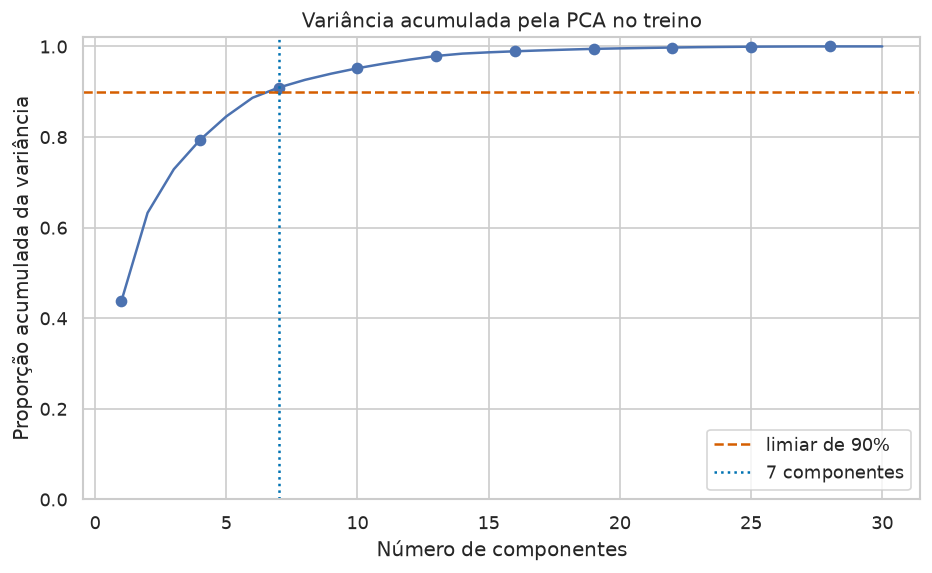

In [5]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
ax.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o", markevery=3)
ax.axhline(0.90, color="#D55E00", linestyle="--", label="limiar de 90%")
ax.axvline(componentes_90, color="#0072B2", linestyle=":", label=f"{componentes_90} componentes")
ax.set(title="Variância acumulada pela PCA no treino", xlabel="Número de componentes", ylabel="Proporção acumulada da variância", ylim=(0, 1.02))
ax.legend()
plt.show()


O limiar de 90% é uma decisão de projeto, não uma lei. Para medir a perda no espaço padronizado, reconstruímos o teste a partir dos componentes e calculamos a raiz do erro quadrático médio (RMSE):

$$\operatorname{RMSE}=\sqrt{\frac{1}{nd}\sum_{i=1}^{n}\sum_{j=1}^{d}(x_{ij}-\hat{x}_{ij})^2}.
$$

Aqui, $n$ é o número de objetos, $d$ o número de atributos e $\hat{x}_{ij}$ o valor reconstruído. Menor RMSE significa reconstrução mais fiel, mas a utilidade final ainda deve ser avaliada na tarefa.


In [6]:
resultados = []
for k in [2, 5, 10, componentes_90]:
    pca = PCA(n_components=k).fit(X_treino_pad)
    reconstruido = pca.inverse_transform(pca.transform(X_teste_pad))
    rmse = np.sqrt(np.mean((X_teste_pad - reconstruido) ** 2))
    resultados.append({"componentes": k, "compressao": k / X.shape[1], "rmse_reconstrucao": rmse})
pd.DataFrame(resultados).drop_duplicates("componentes").round(3)


,componentes,compressao,rmse_reconstrucao
0,2,0.067,0.621
1,5,0.167,0.394
2,10,0.333,0.244
3,7,0.233,0.309


A tabela evidencia o compromisso: mais componentes ocupam maior fração da dimensionalidade original e reduzem o erro de reconstrução. Os componentes misturam atributos e podem dificultar explicações; se interpretabilidade for central, seleção de atributos pode ser preferível.

> **U03-NB03-V01 — Verifique seu entendimento:** por que selecionar o número de componentes usando o conjunto de teste compromete a avaliação final?

> **U03-NB03-E01 — Exercício:** repita a tabela para limiares de variância acumulada de 80%, 90% e 95%. Informe componentes, taxa de compressão e RMSE no teste; recomende uma configuração e explicite seu critério.

> **U03-NB03-E02 — Atividade integradora da unidade:** construa um pipeline reprodutível para uma base propositalmente problemática. Preserve a base bruta; produza diagnóstico antes/depois; separe treino e teste antes de aprender qualquer parâmetro; trate ausências e categorias; aplique uma transformação ou discretização; compare ao menos duas opções de redução; e entregue código, justificativas, indicadores de qualidade e uma seção sobre perdas, vazamento e limitações.


## Síntese

- Redução pode atuar sobre objetos, granularidade ou atributos.
- Preservar uma proporção de classes não garante representatividade completa.
- PCA cria combinações ortogonais ordenadas por variância, após uma decisão consciente sobre escala.
- Compressão deve ser julgada por perda de informação, desempenho, custo e interpretabilidade.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 2, seção 2.5.
- SCIKIT-LEARN DEVELOPERS. *User Guide*: decomposition e PCA. Versão 1.x.
- WOLBERG, William H.; STREET, W. Nick; MANGASARIAN, Olvi L. Breast Cancer Wisconsin (Diagnostic) Data Set. UCI Machine Learning Repository, 1995.
